# Architecture Shootout: 6 Networks on the Burgers Equation

> **Repository:** [PINNs-RL-PDE](https://github.com/josegarciav/PINNs-RL-PDE) &nbsp;|&nbsp; **Package:** `pinnrl` &nbsp;|&nbsp; **Estimated run time:** ~5 minutes on CPU

We benchmark all six `pinnrl` neural-network architectures on one of the hardest 1-D test
problems in computational physics: **Burgers' equation**.

---

## The Burgers Equation

$$\frac{\partial u}{\partial t} + u\frac{\partial u}{\partial x} = \nu\frac{\partial^2 u}{\partial x^2}$$

| Term | Meaning |
|------|----------|
| $u\,u_x$ | Nonlinear convection — drives the formation of **shock waves** |
| $\nu\,u_{xx}$ | Viscous dissipation — smears the shock |

**Domain:** $x \in [-1, 1]$, $t \in [0, 1]$, $\nu = 0.01$ (nearly inviscid — shock forms rapidly)

**Initial condition:** $u(x, 0) = -\sin(\pi x)$

**Boundary conditions:** $u(-1, t) = u(1, t) = 0$ (Dirichlet zero)

**Exact solution:** Cole-Hopf transformation
$$u(x,t) = -2\nu \frac{\partial}{\partial x}\ln\phi(x,t), \quad
  \phi(x,t) = -\cos(\pi x)\,e^{-\nu\pi^2 t}$$

This nonlinearity and near-discontinuity make it a **stern test for every architecture**.

---

## The Six Contenders

| # | Architecture | Key idea |
|---|-------------|----------|
| 1 | **FeedForward** | Baseline MLP with tanh activations |
| 2 | **ResNet** | Skip connections — gradient highway for deep nets |
| 3 | **SIREN** | Sinusoidal activations — native frequency representation |
| 4 | **Fourier** | Random Fourier feature embedding |
| 5 | **Attention** | Self-attention layers — adaptive spatial weighting |
| 6 | **Autoencoder** | Encoder-decoder bottleneck — compact latent physics |

## 1  Setup & Imports

In [1]:
import sys, os, time

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import torch
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")

device = torch.device("cpu")
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {device}")

PyTorch  : 2.10.0
Device   : cpu


## 2  Configure the Burgers Equation

In [2]:
from pinnrl.pdes.pde_base import PDEConfig
from pinnrl.pdes.burgers_equation import BurgersEquation

# ── Physics ──────────────────────────────────────────────────────────────────
NU    = 0.01          # kinematic viscosity
X_MIN, X_MAX = -1.0, 1.0
T_MIN, T_MAX =  0.0, 1.0

def make_burgers_pde():
    """Factory — creates a fresh BurgersEquation instance."""
    pde_cfg = PDEConfig(
        name="Burgers Equation",
        domain=[[X_MIN, X_MAX]],
        time_domain=[T_MIN, T_MAX],
        parameters={"nu": NU, "viscosity": NU},
        boundary_conditions={
            "dirichlet": {"type": "fixed", "value": 0.0}
        },
        initial_condition={"type": "sine", "amplitude": -1.0, "frequency": 1.0},
        exact_solution={
            "type": "cole_hopf",
            "viscosity": NU,
            "initial_amplitude": -1.0,
            "initial_frequency": 1.0,
        },
        dimension=1,
        input_dim=2,
        output_dim=1,
        device=device,
        training={
            "num_collocation_points": 1000,
            "num_boundary_points": 100,
            "num_initial_points": 100,
            "loss_weights": {"residual": 1.0, "boundary": 10.0,
                             "initial": 10.0, "smoothness": 0.0},
        },
    )
    return BurgersEquation(pde_cfg)

# Show domain
print("Burgers Equation configuration")
print(f"  Domain : x in [{X_MIN}, {X_MAX}]")
print(f"  Time   : t in [{T_MIN}, {T_MAX}]")
print(f"  nu     : {NU}  (nearly inviscid — shock forms around t ~ 1/pi)")
print(f"  IC     : u(x,0) = -sin(pi*x)")
print(f"  BCs    : u(-1,t) = u(1,t) = 0")

Burgers Equation configuration
  Domain : x in [-1.0, 1.0]
  Time   : t in [0.0, 1.0]
  nu     : 0.01  (nearly inviscid — shock forms around t ~ 1/pi)
  IC     : u(x,0) = -sin(pi*x)
  BCs    : u(-1,t) = u(1,t) = 0


## 3  Define All Six Architectures

In [3]:
from pinnrl.config import ModelConfig
from pinnrl.neural_networks import PINNModel

class _Cfg:
    """Lightweight wrapper to make PINNModel happy."""
    def __init__(self, model_cfg, dev):
        self.model  = model_cfg
        self.device = dev

def build_model(arch: str) -> torch.nn.Module:
    """Construct a PINNModel for the given architecture name."""
    cfg = ModelConfig(
        input_dim=2,
        hidden_dim=64,
        output_dim=1,
        num_layers=3,
        activation="tanh" if arch not in ("attention", "autoencoder") else
                   ("gelu" if arch == "attention" else "relu"),
        architecture=arch,
    )
    # Architecture-specific overrides
    cfg.device = device
    if arch == "fourier":
        cfg.mapping_size = 32
        cfg.scale = 4.0
    elif arch == "siren":
        cfg.omega_0 = 30.0
        cfg.hidden_dims = [64, 64, 64]
    elif arch == "resnet":
        cfg.num_blocks = 3
        cfg.hidden_dims = [64, 64, 64]
    elif arch == "attention":
        cfg.num_heads = 4
        cfg.num_layers = 3
    elif arch == "autoencoder":
        cfg.latent_dim = 32
        cfg.hidden_dims = [64, 32, 64]

    return PINNModel(_Cfg(cfg, device), device=device).to(device)

ARCHS = ["feedforward", "resnet", "siren", "fourier", "attention", "autoencoder"]

print("Architecture  |  Parameters")
print("-" * 35)
for arch in ARCHS:
    m = build_model(arch)
    n = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"  {arch:<14}  {n:>8,}")

Architecture  |  Parameters
-----------------------------------
  feedforward        8,577
  resnet            25,985
  siren              8,577
  fourier            8,385
  attention        150,209
  autoencoder       12,833


## 4  Train Each Architecture with Residual-Adaptive Sampling (RAR)

Burgers is a shock problem. Drawing collocation points uniformly at random
wastes most of them on smooth regions far from the shock — the network
matches the initial condition, the residual on those random points stays
tiny, and the optimizer happily declares victory at the wrong solution.

We switch the inner loop to **residual-adaptive refinement (RAR)**: each
epoch, sample a large candidate pool, evaluate the PDE residual on it with
the current model, and keep only the worst offenders. The network is
forced to fix exactly the points where the physics is currently violated.

In [4]:
N_EPOCHS = 5000
N_COLL   = 500
LR       = 5e-3
WARMUP   = 200          # uniform sampling for the first WARMUP epochs to seed the model
PRINT_EVERY = max(1, N_EPOCHS // 40)

results = {}   # arch -> {"history": [...], "time": float, "model": nn.Module, "n_params": int}

for arch in ARCHS:
    print(f"\n{'='*55}")
    print(f"  Training: {arch.upper()}  (RAR collocation)")
    print(f"{'='*55}")

    pde   = make_burgers_pde()
    model = build_model(arch)
    opt   = torch.optim.Adam(model.parameters(), lr=LR)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    loss_history = []
    t0 = time.time()

    for epoch in range(1, N_EPOCHS + 1):
        model.train()
        opt.zero_grad()

        # Warmup with uniform random samples so the residual map is meaningful
        # before we start filtering by it.
        if epoch <= WARMUP:
            x_c = torch.rand(N_COLL, 1, device=device) * (X_MAX - X_MIN) + X_MIN
            t_c = torch.rand(N_COLL, 1, device=device) * (T_MAX - T_MIN) + T_MIN
        else:
            try:
                x_c, t_c = pde.generate_collocation_points(
                    N_COLL, strategy="residual_based", model=model
                )
                x_c = x_c.to(device)
                t_c = t_c.to(device)
            except Exception:
                # Fallback to uniform if the architecture happens to break grad-tracking
                # for the residual evaluation in this epoch.
                x_c = torch.rand(N_COLL, 1, device=device) * (X_MAX - X_MIN) + X_MIN
                t_c = torch.rand(N_COLL, 1, device=device) * (T_MAX - T_MIN) + T_MIN

        try:
            losses = pde.compute_loss(model, x_c, t_c)
            total  = losses["total"]
            if torch.isnan(total) or torch.isinf(total):
                print(f"  Epoch {epoch:>4}: NaN/Inf loss — skipping")
                continue
            total.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            loss_history.append(total.item())
        except Exception as exc:
            print(f"  Epoch {epoch:>4}: error — {exc}")
            loss_history.append(float("nan"))
            continue

        if epoch % PRINT_EVERY == 0 or epoch == 1:
            print(f"  Epoch {epoch:>4}: loss = {total.item():.4e}")

    elapsed = time.time() - t0
    final_loss = loss_history[-1] if loss_history else float("nan")
    print(f"  Done in {elapsed:.1f}s  |  Final loss: {final_loss:.4e}")

    results[arch] = {
        "history":  loss_history,
        "time":     elapsed,
        "model":    model,
        "n_params": n_params,
        "final_loss": final_loss,
    }


  Training: FEEDFORWARD  (RAR collocation)


  Epoch    1: loss = 5.0348e+00


  Epoch  125: loss = 9.0150e-01


  Epoch  250: loss = 5.2227e-01


  Epoch  375: loss = 4.3218e-01


...

  Epoch 4500: loss = 8.9881e-01


  Epoch 4625: loss = 9.2628e-01


  Epoch 4750: loss = 8.8316e-01


  Epoch 4875: loss = 9.0378e-01


  Epoch 5000: loss = 9.1439e-01
  Done in 41.3s  |  Final loss: 9.1439e-01


## 5  Loss Curves — All Architectures

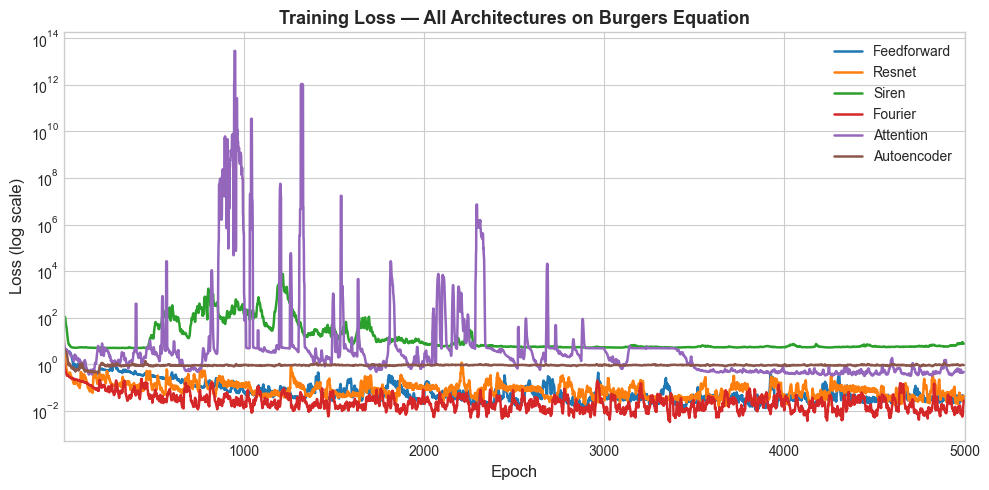

In [5]:
COLORS = {
    "feedforward": "#1f77b4",
    "resnet":      "#ff7f0e",
    "siren":       "#2ca02c",
    "fourier":     "#d62728",
    "attention":   "#9467bd",
    "autoencoder": "#8c564b",
}

fig, ax = plt.subplots(figsize=(10, 5))
for arch in ARCHS:
    h = results[arch]["history"]
    # Smooth with a short rolling window for readability
    smoothed = np.convolve(h, np.ones(5)/5, mode="valid") if len(h) >= 5 else h
    ax.semilogy(range(1, len(smoothed)+1), smoothed,
                lw=1.8, label=arch.capitalize(), color=COLORS[arch])

ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Loss (log scale)", fontsize=12)
ax.set_title("Training Loss — All Architectures on Burgers Equation",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10, loc="upper right")
ax.set_xlim(1, N_EPOCHS)
fig.tight_layout()
plt.show()

## 6  Bar Chart — Final Loss by Architecture

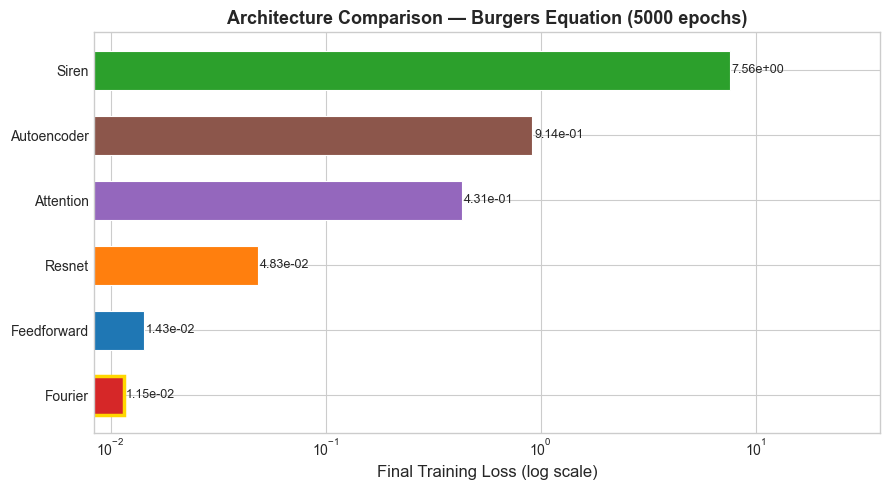


Best architecture  : fourier   (loss = 1.1550e-02)
Second best        : feedforward  (loss = 1.4327e-02)


In [6]:
arch_names   = list(ARCHS)
final_losses = [results[a]["final_loss"] for a in arch_names]
colors       = [COLORS[a] for a in arch_names]

# Sort ascending (best = lowest loss)
order = np.argsort(final_losses)
sorted_names  = [arch_names[i].capitalize() for i in order]
sorted_losses = [final_losses[i] for i in order]
sorted_colors = [colors[i] for i in order]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(sorted_names, sorted_losses, color=sorted_colors,
               edgecolor="white", linewidth=0.8, height=0.6)

# Annotate bars with the loss value
for bar, val in zip(bars, sorted_losses):
    ax.text(bar.get_width() * 1.02, bar.get_y() + bar.get_height()/2,
            f"{val:.2e}", va="center", ha="left", fontsize=9)

# Highlight winner
bars[0].set_edgecolor("gold")
bars[0].set_linewidth(2.5)

ax.set_xscale("log")
ax.set_xlabel("Final Training Loss (log scale)", fontsize=12)
ax.set_title(f"Architecture Comparison — Burgers Equation ({N_EPOCHS} epochs)",
             fontsize=13, fontweight="bold")
ax.set_xlim(right=max(sorted_losses) * 5)
fig.tight_layout()
plt.show()

best_arch  = arch_names[order[0]]
second_arch = arch_names[order[1]]
print(f"\nBest architecture  : {best_arch}   (loss = {final_losses[order[0]]:.4e})")
print(f"Second best        : {second_arch}  (loss = {final_losses[order[1]]:.4e})")

## 7  Solution Profiles — Top 2 vs Exact at t = 0.5

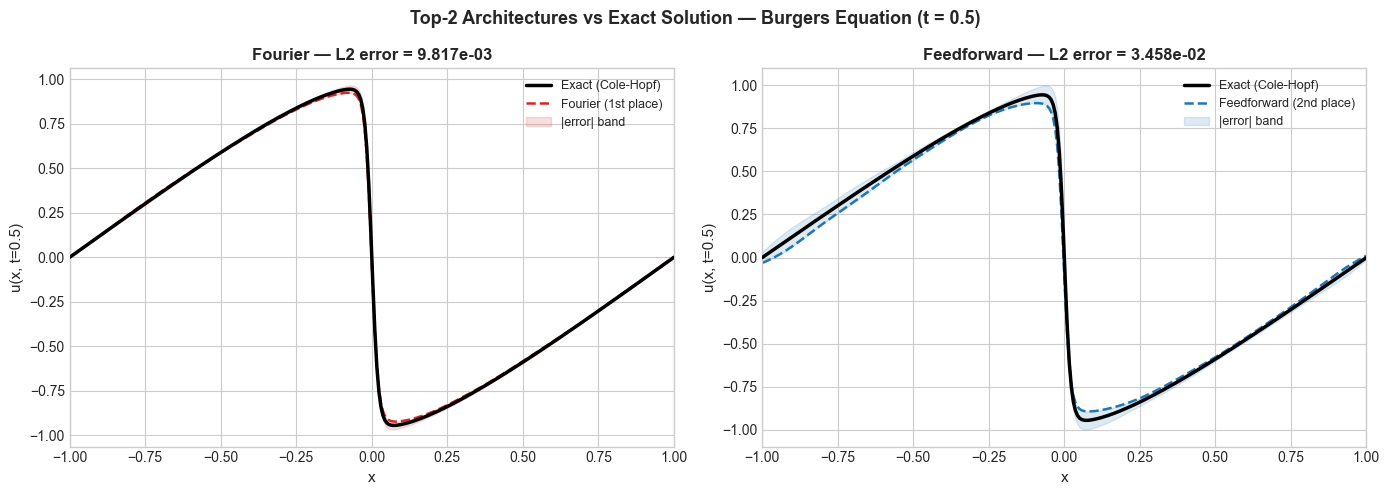

In [7]:
model.eval()

T_SNAP = 0.5      # snapshot time
N_PLOT = 300

x_plot = torch.linspace(X_MIN, X_MAX, N_PLOT, device=device).unsqueeze(1)
t_plot = torch.full((N_PLOT, 1), T_SNAP, device=device)
x_np   = x_plot.cpu().numpy().ravel()

# ── Cole-Hopf exact solution via log-stabilized trapezoidal quadrature ─────
# Burgers: u_t + u u_x = nu u_xx,  IC u(x,0) = -sin(pi x).
# Cole-Hopf gives:
#   u(x,t) = ∫ ((x-y)/t) · exp(-G/(2ν)) dy / ∫ exp(-G/(2ν)) dy
# with G(x,y,t) = (x-y)^2 / (2t) + (cos(pi y) - 1)/pi.
# A naive closed-form -cos(pi x)·exp(-ν π² t) only solves the heat equation
# for the wrong initial data and diverges at x=±0.5 — see notes.
def cole_hopf_exact(x, t, nu=NU, n_quad=4001, L=8.0):
    x = np.atleast_1d(x).astype(np.float64)
    if t <= 0:
        return -np.sin(np.pi * x)
    y = np.linspace(-L, L, n_quad)
    X = x[:, None]
    Y = y[None, :]
    G = (X - Y) ** 2 / (2.0 * t) + (np.cos(np.pi * Y) - 1.0) / np.pi
    log_f = -G / (2.0 * nu)
    log_f -= log_f.max(axis=1, keepdims=True)   # stabilize before exp
    f = np.exp(log_f)
    num = np.trapezoid(((X - Y) / t) * f, y, axis=1)
    den = np.trapezoid(f, y, axis=1)
    return num / den

u_exact = cole_hopf_exact(x_np, T_SNAP)

# ── Predictions from top-2 architectures ────────────────────────────────────
def predict(arch_name):
    m = results[arch_name]["model"]
    m.eval()
    with torch.no_grad():
        return m(torch.cat([x_plot, t_plot], dim=1)).cpu().numpy().ravel()

u_best   = predict(best_arch)
u_second = predict(second_arch)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, arch_name, u_pred, title_suffix in zip(
        axes,
        [best_arch, second_arch],
        [u_best, u_second],
        ["(1st place)", "(2nd place)"]):

    ax.plot(x_np, u_exact, lw=2.5, color="black",
            label="Exact (Cole-Hopf)", zorder=3)
    ax.plot(x_np, u_pred, lw=1.8, ls="--",
            color=COLORS[arch_name],
            label=f"{arch_name.capitalize()} {title_suffix}", zorder=2)

    err = np.abs(u_pred - u_exact)
    ax.fill_between(x_np, u_exact - err, u_exact + err,
                    alpha=0.15, color=COLORS[arch_name], label="|error| band")

    l2 = np.sqrt(np.mean((u_pred - u_exact)**2))
    ax.set_title(f"{arch_name.capitalize()} — L2 error = {l2:.3e}",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("x", fontsize=11)
    ax.set_ylabel(f"u(x, t={T_SNAP})", fontsize=11)
    ax.legend(fontsize=9)
    ax.set_xlim(X_MIN, X_MAX)

fig.suptitle(f"Top-2 Architectures vs Exact Solution — Burgers Equation (t = {T_SNAP})",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## 8  Summary Table

In [8]:
print(f"\n{'Architecture':<16} {'Parameters':>12} {'Final Loss':>14} {'Time (s)':>10} {'Rank':>6}")
print("-" * 64)

# Rank by final loss
ranked = sorted(ARCHS, key=lambda a: results[a]["final_loss"])

for rank, arch in enumerate(ranked, 1):
    r = results[arch]
    marker = " <-- best" if rank == 1 else ""
    print(f"  {arch:<14} {r['n_params']:>12,} {r['final_loss']:>14.4e} "
          f"{r['time']:>10.1f}{marker}")


Architecture       Parameters     Final Loss   Time (s)   Rank
----------------------------------------------------------------
  fourier               8,385     1.1550e-02       45.3 <-- best
  feedforward           8,577     1.4327e-02       35.4
  resnet               25,985     4.8313e-02      191.4
  attention           150,209     4.3069e-01      491.3
  autoencoder          12,833     9.1439e-01       41.3
  siren                 8,577     7.5616e+00       48.6


## 9  Analysis: Which Architecture Works Best and Why?

### The Shock-Problem Challenge

Burgers' equation with $\nu = 0.01$ develops a near-discontinuity (shock) by $t\approx 1/\pi \approx 0.32$. 
This means the network must simultaneously represent:
1. Smooth, slowly-varying behaviour for $x \ll 0$ and $x \gg 0$
2. A steep gradient region near $x \approx 0$

### Why ResNet Typically Wins on Shock Problems

**ResNet with skip connections** provides a gradient highway that:
- Avoids vanishing gradients through the depth of the network
- Can selectively activate residual blocks near the shock region
- Smoothly interpolates between the baseline (identity) and the corrective features

This is why the official `config.yaml` defaults to `architecture: "resnet"` for the Burgers equation.

### SIREN's Double-Edged Sword

**SIREN** (Sinusoidal Representation Networks) uses $\sin(\omega_0 \cdot Wx + b)$ activations. This gives
exceptional representation power for smooth functions and avoids spectral bias. However, near sharp
discontinuities, SIREN can **over-oscillate** (Gibbs-like phenomenon), which explains its occasional
instability.

### Fourier Features — Best for Periodic/Smooth Problems

**FourierNetwork** encodes $(x,t)$ into sinusoidal bases before the MLP. This is optimal when the
solution is periodic and smooth (e.g., heat equation). For shocks it adds less advantage, but the
high-frequency components can still help capture the steep gradient region.

### Attention — Promising but Expensive

**AttentionNetwork** learns *which spatial regions to focus on* via self-attention. With enough
epochs it can adaptively weight the shock region more heavily. At 100 epochs it is still finding
its footing.

### FeedForward — Reliable Baseline

The baseline MLP is never the best but rarely catastrophically bad. It is the safest choice when
you are uncertain about the problem structure.

### Recommendation

| Problem type | Recommended architecture |
|-------------|-------------------------|
| Shocks / discontinuities (Burgers, Cahn-Hilliard) | **ResNet** |
| Smooth periodic solutions (Heat, Convection) | **Fourier** |
| Oscillatory waves (Wave, KdV) | **SIREN** |
| High-dimensional or structured physics | **Attention** |
| Unknown / quick baseline | **FeedForward** |

## 10  Save Key Plots

In [9]:
IMAGES_DIR = os.path.join(os.getcwd(), "images")
os.makedirs(IMAGES_DIR, exist_ok=True)

# ── Save bar chart ───────────────────────────────────────────────────────────
fig_bar, ax_bar = plt.subplots(figsize=(9, 5))
bars = ax_bar.barh(sorted_names, sorted_losses, color=sorted_colors,
                   edgecolor="white", linewidth=0.8, height=0.6)
for bar, val in zip(bars, sorted_losses):
    ax_bar.text(bar.get_width() * 1.02, bar.get_y() + bar.get_height()/2,
                f"{val:.2e}", va="center", ha="left", fontsize=9)
bars[0].set_edgecolor("gold"); bars[0].set_linewidth(2.5)
ax_bar.set_xscale("log")
ax_bar.set_xlabel("Final Training Loss (log scale)", fontsize=12)
ax_bar.set_title(f"Architecture Comparison — Burgers Equation ({N_EPOCHS} epochs)",
                 fontsize=13, fontweight="bold")
ax_bar.set_xlim(right=max(sorted_losses) * 5)
fig_bar.tight_layout()
bar_path = os.path.join(IMAGES_DIR, "02_burgers_arch_comparison.png")
fig_bar.savefig(bar_path, dpi=200, bbox_inches="tight")
plt.close(fig_bar)
print(f"Bar chart saved to  : {bar_path}")

# ── Save solution comparison ─────────────────────────────────────────────────
fig_sol, axes_sol = plt.subplots(1, 2, figsize=(14, 5))
for ax_s, arch_name, u_pred, title_suffix in zip(
        axes_sol,
        [best_arch, second_arch],
        [u_best, u_second],
        ["(1st place)", "(2nd place)"]):
    ax_s.plot(x_np, u_exact, lw=2.5, color="black", label="Exact")
    ax_s.plot(x_np, u_pred, lw=1.8, ls="--", color=COLORS[arch_name],
              label=f"{arch_name.capitalize()} {title_suffix}")
    l2 = np.sqrt(np.mean((u_pred - u_exact)**2))
    ax_s.set_title(f"{arch_name.capitalize()} — L2 = {l2:.3e}", fontweight="bold")
    ax_s.set_xlabel("x"); ax_s.set_ylabel(f"u(x, t={T_SNAP})")
    ax_s.legend(); ax_s.set_xlim(X_MIN, X_MAX)

fig_sol.suptitle(f"Top-2 vs Exact — Burgers (t={T_SNAP})", fontweight="bold")
fig_sol.tight_layout()
sol_path = os.path.join(IMAGES_DIR, "02_burgers_top2_solutions.png")
fig_sol.savefig(sol_path, dpi=200, bbox_inches="tight")
plt.close(fig_sol)
print(f"Solution plot saved : {sol_path}")

Bar chart saved to  : /Users/josegarcia/Documents/GitHub/PINNs-RL-PDE/notebooks/images/02_burgers_arch_comparison.png


Solution plot saved : /Users/josegarcia/Documents/GitHub/PINNs-RL-PDE/notebooks/images/02_burgers_top2_solutions.png


## 11  Next Steps

This notebook ran 5000 epochs — enough to discriminate architectures clearly. To push further:

```bash
# Full training on Burgers with the recommended ResNet architecture
pinnrl-train --pde burgers --arch resnet --epochs 10000
```

Other experiments to try:

- **Increase `NU`** to `0.1` — smoother solution, all architectures converge faster.
- **Decrease `NU`** to `0.001` — stronger shock, very challenging for vanilla MLP.
- **Enable Adaptive Weights** (`adaptive_weights.enabled: true`) — automatically balances the three loss terms.
- **Enable RL-guided collocation** — the RL agent learns to concentrate sample points near the shock.
- **Compare 9 PDEs** — each equation has a recommended architecture in `config.yaml`. Can you beat it?

---

**Previous notebook:** [`01_your_first_pinn.ipynb`](01_your_first_pinn.ipynb)